<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula14a_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:,2:4]
y = data.target

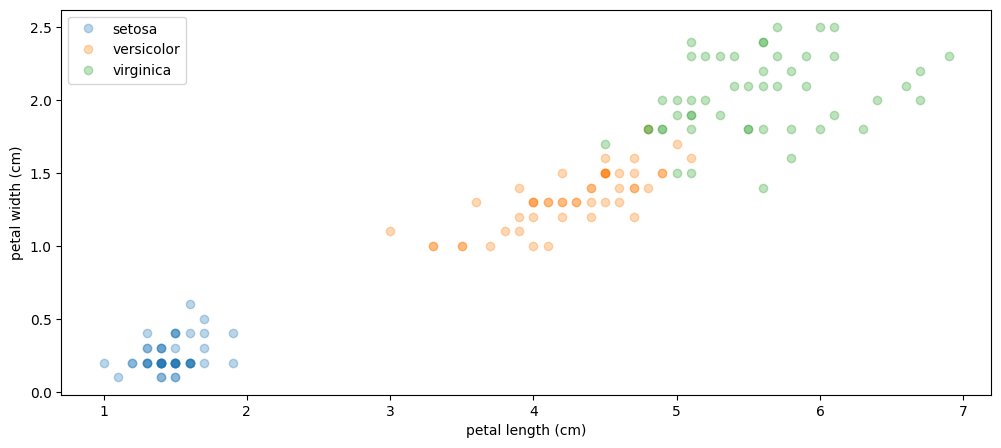

In [53]:
import matplotlib.pyplot as plt

feature_names = data.feature_names[2:4]
target_names = data.target_names

def plot_dataset(X, y, feature_names=feature_names, target_names=target_names):
  for i in range(len(set(y))):
    plt.plot(X[y==i,0], X[y==i, 1], 'o', label=target_names[i], alpha=0.3)
  plt.xlabel(feature_names[0])
  plt.ylabel(feature_names[1])
  plt.legend()

plt.figure(figsize=(12, 5))
plot_dataset(X, y)
plt.show()

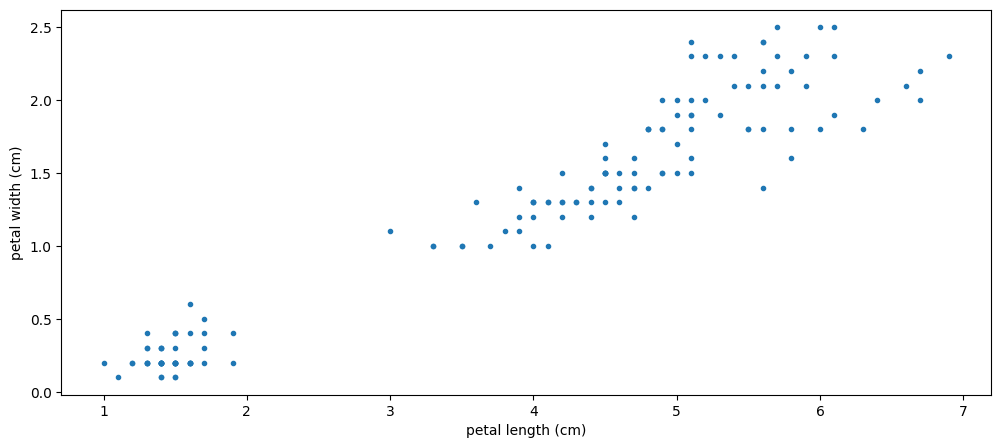

In [54]:
plt.figure(figsize=(12, 5))
plt.scatter(X[:, 0], X[:, 1], marker='.')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()

In [24]:
from sklearn.base import BaseEstimator, ClusterMixin, TransformerMixin
import numpy as np
import random

class KMeans(BaseEstimator, ClusterMixin, TransformerMixin):
  def __init__(self, n_clusters=3, max_iter=100):
    self.n_clusters = n_clusters
    self.max_iter = max_iter

  def fit(self, X, y=None):
    self.centroids = X[random.sample(range(len(X)), self.n_clusters)]
    self.previous_centroids = []
    self.previous_centroids.append(self.centroids.copy())
    for _ in range(self.max_iter):
      y_pred = self.predict(X)
      for i in range(self.n_clusters):
        self.centroids[i] = np.mean(X[y_pred==i], axis=0)
      if np.allclose(self.centroids, self.previous_centroids[-1], atol=1e-9):
        break
      self.previous_centroids.append(self.centroids.copy())
    return self

  def distances(self, x):
    differences = x - self.centroids
    squared = differences ** 2
    summed = np.sum(squared, axis=1)
    root = np.sqrt(summed)
    return root

  def predict(self, X):
    y_pred = np.empty((X.shape[0],))
    for i in range(X.shape[0]):
      distances = self.distances([X[i]])
      y_pred[i] = np.argmin(distances)
    return y_pred



kmeans = KMeans(3)
kmeans.fit(X)
print(kmeans.centroids)
print(len(kmeans.previous_centroids))

[[4.29259259 1.35925926]
 [1.462      0.246     ]
 [5.62608696 2.04782609]]
2


[[5.62608696 2.04782609]
 [1.462      0.246     ]
 [4.29259259 1.35925926]]
7


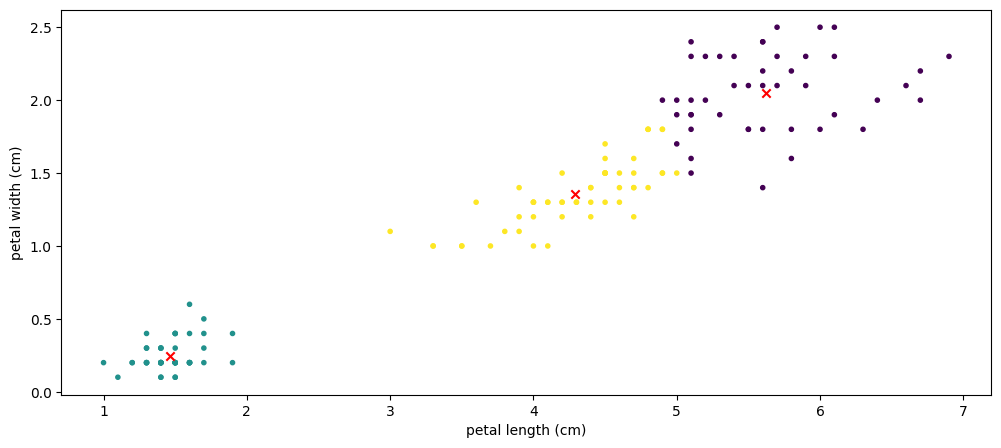

In [55]:
kmeans = KMeans(3)
kmeans.fit(X)
print(kmeans.centroids)
print(len(kmeans.previous_centroids))

y_pred = kmeans.predict(X)
plt.figure(figsize=(12, 5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, marker='.')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='x')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()

15


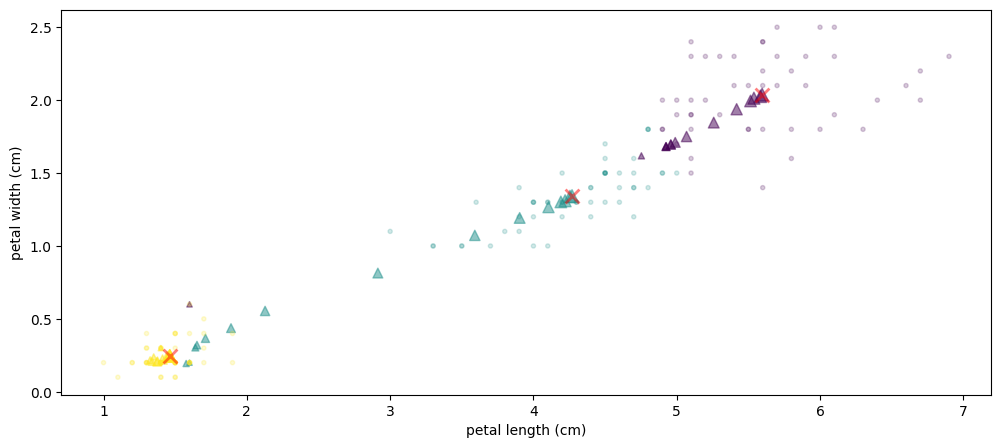

In [56]:
kmeans = KMeans(3)
kmeans.fit(X)
print(len(kmeans.previous_centroids))
y_pred = kmeans.predict(X)

plt.figure(figsize=(12, 5))
for i in range(len(kmeans.previous_centroids)):
  previous_centroid = kmeans.previous_centroids[i]
  plt.scatter(previous_centroid[:, 0], previous_centroid[:, 1],
              c=list(set(y_pred)), marker='^', alpha=0.5, s=5*(i+3))

plt.scatter(X[:, 0], X[:, 1], c=y_pred, marker='.', alpha=0.2)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='x', s=100, linewidths=2, alpha=0.5)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()

In [48]:
def define_axes(X):
    offset = 0.1
    min1, max1 = X[:, 0].min(), X[:, 0].max()
    min2, max2 = X[:, 1].min(), X[:, 1].max()
    return [min1-offset, max1+offset, min2-offset, max2+offset]

def plot_predictions(clf, X):
    axes = define_axes(X)
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

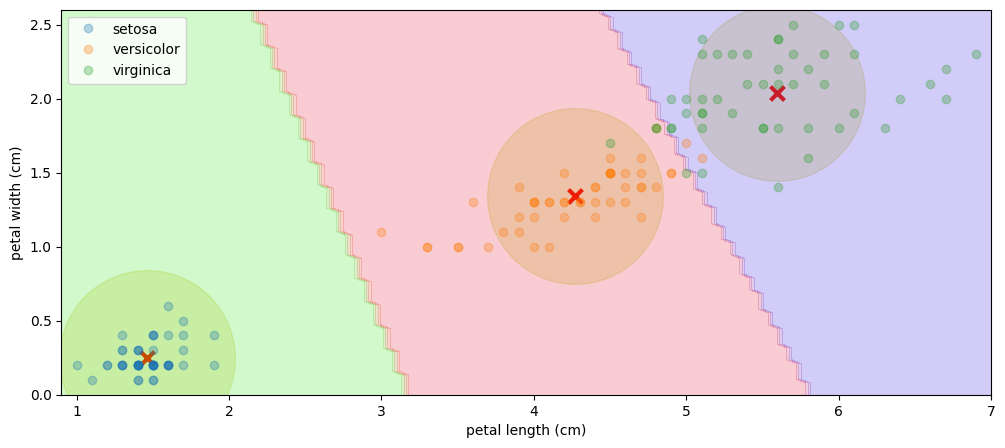

In [61]:
plt.figure(figsize=(12, 5))
plot_dataset(X, y)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            marker='x', color='r', s=100, linewidths=3)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            marker='o', color='y', s=16000, linewidths=1, alpha=0.2)
plot_predictions(kmeans, X)
plt.show()